# Алгоритм градиентного спуска


# 1. Импорт библиотек и генерация датасета

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

In [2]:
X_raw, y = make_regression(n_samples=300, n_features=5, n_informative=4, noise=15.0, random_state=42)
print(f'Размер матрицы признаков: {X_raw.shape}')
print(f'Размер вектора ответов:   {y.shape}')

Размер матрицы признаков: (300, 5)
Размер вектора ответов:   (300,)


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

ones = np.ones((X_scaled.shape[0], 1))
X = np.hstack([ones, X_scaled])

print(f'Итоговая форма X (с bias): {X.shape}')

Итоговая форма X (с bias): (300, 6)


# 2. Вспомогательные функции

In [4]:
def mse(X, w, y):
  residuals = X.dot(w) - y
  return np.dot(residuals, residuals) / len(y)

def gradient(X, w, y):
  return (2.0 / len(y)) * X.T.dot(X.dot(w) - y)

# 3. Градиентный спуск (пакетный)

In [5]:
def gradient_descent(X, y, eta=0.01, max_iter=10000, eps=1e-8):
  w = np.zeros(X.shape[1])
  weight_dist = np.inf
  errors = []
  iteration = 0

  while weight_dist > eps and iteration < max_iter:
    grad = gradient(X, w, y)
    w_new = w - eta * grad
    weight_dist = np.linalg.norm(w_new - w, ord=2)
    errors.append(mse(X, w_new, y))
    w = w_new
    iteration += 1

  print(f'Пакетный градиентный спуск - итераций: {iteration}, финальная MSE: {errors[-1]:.4f}')
  return w, errors

# 4. Эксперименты со скоростью обучения

Пакетный градиентный спуск - итераций: 500, финальная MSE: 1596.7410
Пакетный градиентный спуск - итераций: 500, финальная MSE: 216.6732
Пакетный градиентный спуск - итераций: 225, финальная MSE: 216.6731
Пакетный градиентный спуск - итераций: 112, финальная MSE: 216.6731
Пакетный градиентный спуск - итераций: 13, финальная MSE: 216.6731


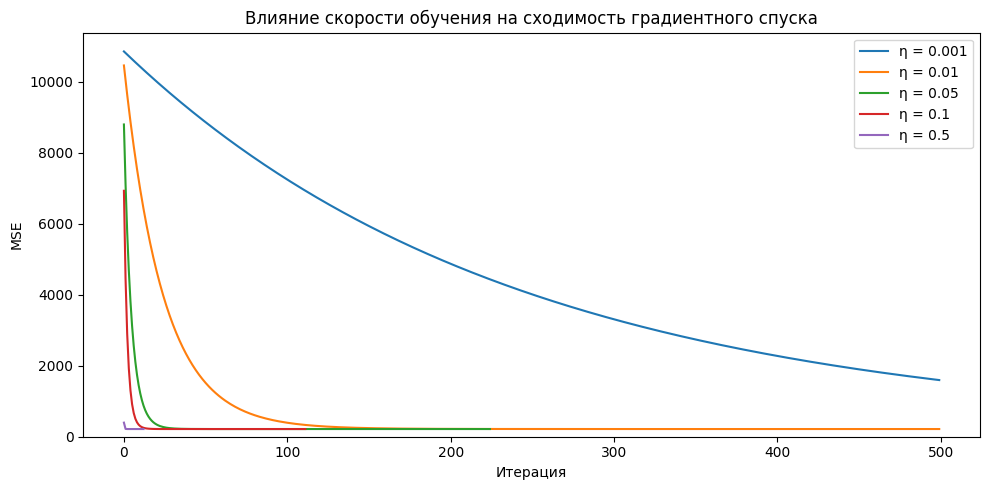

In [6]:
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5]

fig, ax = plt.subplots(figsize=(10, 5))

for eta in learning_rates:
  _, errs = gradient_descent(X, y, eta=eta, max_iter=500)
  ax.plot(errs, label=f'η = {eta}')

ax.set_xlabel('Итерация')
ax.set_ylabel('MSE')
ax.set_title('Влияние скорости обучения на сходимость градиентного спуска')
ax.legend()
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

Вывод по скорости обучения:

*   При η = 0.001 сходимость крайне медленная: за 500 итераций ошибка снизилась лишь до ~1597, не достигнув минимума.
*   При η = 0.01 сходимость заметно быстрее, однако алгоритм всё ещё не успел полностью сойтись за 500 итераций (финальная MSE ~217).
*   При η = 0.05 алгоритм сошёлся за 225 итераций, достигнув MSE ≈ 216.67.
*   При η = 0.1 сходимость в два раза быстрее - всего 112 итераций при той же финальной ошибке.
*   При η = 0.5 алгоритм сошёлся всего за 13 итераций - наиболее быстрый результат без каких-либо признаков расходимости.


Таким образом, на данном датасете после масштабирования признаков даже относительно большое значение η = 0.5 работает стабильно. Все варианты, кроме η = 0.001 и η = 0.01, сходятся к одному и тому же минимуму MSE ≈ 216.67, что говорит о выпуклости функции потерь. Чем больше шаг - тем быстрее сходимость.

# 5. Стохастический градиентный спуск

In [7]:
def stochastic_gradient_descent(X, y, eta=0.01, max_iter=10000, eps=1e-8):

  w = np.zeros(X.shape[1])
  weight_dist = np.inf
  errors = []
  iteration = 0

  while weight_dist > eps and iteration < max_iter:
    idx = np.random.randint(X.shape[0], size=1)
    X_i = X[idx]
    y_i = y[idx]
    grad = (2.0 / len(y_i)) * X_i.T.dot(X_i.dot(w) - y_i)
    w_new = w - eta * grad
    weight_dist = np.linalg.norm(w_new - w, ord=2)
    errors.append(mse(X, w_new, y))
    w = w_new
    iteration += 1

  print(f'Стохастический градиентный спуск - итераций: {iteration}, финальная MSE: {errors[-1]:.4f}')
  return w, errors

# 6. Сравнение пакетного градиентного спуска и стохастического градиентного спуска на одном графике

Пакетный градиентный спуск - итераций: 112, финальная MSE: 216.6731
Стохастический градиентный спуск - итераций: 300, финальная MSE: 609.0159


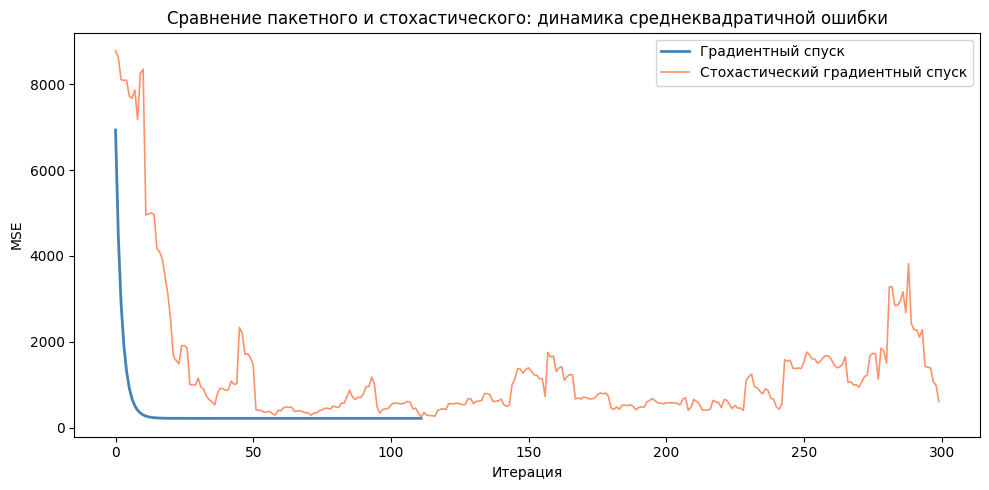

In [8]:
ETA = 0.1
MAX_ITER = 300

w_gd, errors_gd = gradient_descent(X, y, eta=ETA, max_iter=MAX_ITER)
w_sgd, errors_sgd = stochastic_gradient_descent(X, y, eta=ETA, max_iter=MAX_ITER)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(errors_gd, label='Градиентный спуск', color='steelblue', linewidth=2)
ax.plot(errors_sgd, label='Стохастический градиентный спуск', color='coral', linewidth=1.2, alpha=0.85)

ax.set_xlabel('Итерация')
ax.set_ylabel('MSE')
ax.set_title('Сравнение пакетного и стохастического: динамика среднеквадратичной ошибки')
ax.legend()
plt.tight_layout()
plt.show()

Пакетный ГС сходится плавно и стабильно - за 112 итераций ошибка монотонно упала до 216.67 и алгоритм остановился.

Стохастический ГС ведёт себя заметно хуже: кривая шумная, есть резкие выбросы, и за 300 итераций финальная MSE составила лишь 609. Это объясняется тем, что градиент считается по одному случайному объекту, который может быть "нетипичным" и уводить веса не туда.

В целом пакетный ГС точнее и стабильнее, но стохастический ГС дешевле вычислительно - каждая итерация требует в n раз меньше операций, что важно при больших объёмах данных.

# 7. L2 регуляризация (Ridge)

In [9]:
def gradient_descent_l2(X, y, alpha=0.1, eta=0.1, max_iter=5000, eps=1e-8):
  n_features = X.shape[1]
  w = np.zeros(n_features)
  reg_mask = np.ones(n_features)
  reg_mask[0] = 0.0
  weight_dist = np.inf
  iteration = 0

  while weight_dist > eps and iteration < max_iter:
    grad = gradient(X, w, y) + 2.0 * alpha * reg_mask * w
    w_new = w - eta * grad

    weight_dist = np.linalg.norm(w_new - w, ord=2)
    w = w_new
    iteration += 1

  return w

In [10]:
alphas = np.logspace(-3, 3, 20)
weight_matrix = []
for alpha in alphas:
  w_reg = gradient_descent_l2(X, y, alpha=alpha, eta=0.1)
  weight_matrix.append(w_reg)
weight_matrix = np.array(weight_matrix)

/tmp/ipykernel_2094/2522687956.py:10: RuntimeWarning: overflow encountered in multiply
  grad = gradient(X, w, y) + 2.0 * alpha * reg_mask * w
/tmp/ipykernel_2094/2522687956.py:11: RuntimeWarning: invalid value encountered in subtract
  w_new = w - eta * grad
/tmp/ipykernel_2094/2522687956.py:10: RuntimeWarning: invalid value encountered in multiply
  grad = gradient(X, w, y) + 2.0 * alpha * reg_mask * w


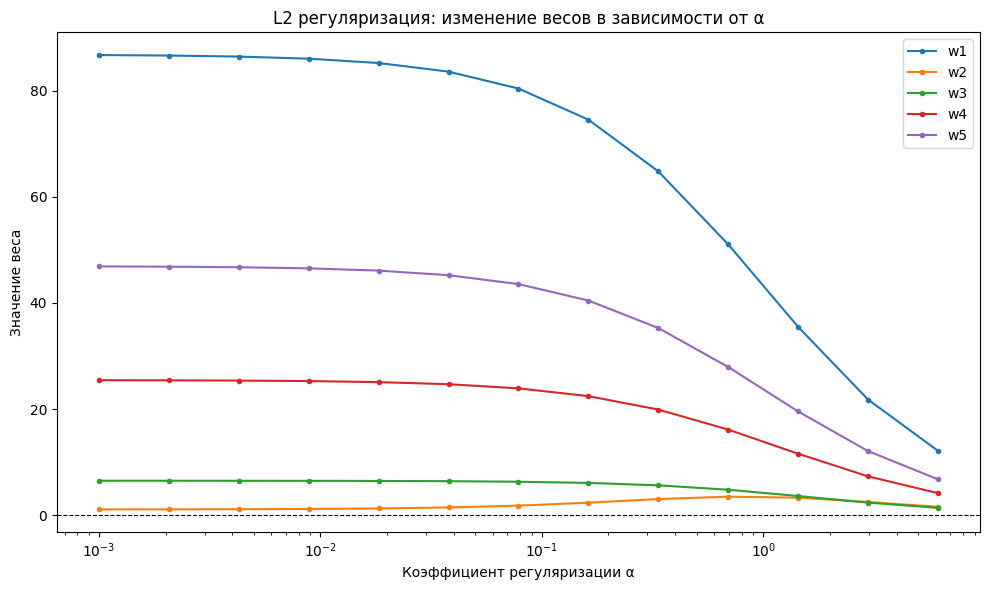

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
n_features_total = weight_matrix.shape[1]
for j in range(1, n_features_total):
    ax.plot(alphas, weight_matrix[:, j], marker='o', markersize=3, label=f'w{j}')
ax.set_xscale('log')
ax.set_xlabel('Коэффициент регуляризации α')
ax.set_ylabel('Значение веса')
ax.set_title('L2 регуляризация: изменение весов в зависимости от α')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend()
plt.tight_layout()
plt.show()

По оси X - коэффициент регуляризации α (в логарифмическом масштабе от 0.001 до ~10),

по оси Y - значения весов модели.

Каждая линия (w1–w5) соответствует одному признаку из датасета.

Вывод:

При малых α (≈ 0.001) регуляризация почти не влияет на веса — они остаются близкими к значениям без штрафа. По мере роста α штраф за большие веса усиливается, и все веса начинают монотонно стягиваться к нулю. Причём веса уменьшаются плавно и ни один из них не обнуляется полностью - это характерное отличие L2 от L1, которая зануляет веса резко.

Оптимальный диапазон α следует подбирать по метрикам на валидационной выборке.


# 8. Выводы


1. **Градиентный спуск** находит минимум MSE путём итеративного смещения весов в сторону антиградиента. Ключевой гиперпараметр - скорость обучения η: слишком большая вызывает расходимость, слишком маленькая - медленную сходимость.

2. **Стохастический ГС** вычисляет градиент по одному случайному объекту, что делает каждую итерацию намного дешевле, но кривая ошибки становится зашумлённой. В целом SGD сходится быстрее по времени при большом объёме данных.

3. **L2 регуляризация** добавляет штраф пропорциональный сумме квадратов весов. Это заставляет модель держать веса небольшими, снижая переобучение. Гиперпараметр α управляет силой ограничения: чем он выше, тем меньше веса и проще модель.